# Deepening Embedded Drug-Target Interactions with ConPLex

The models developed for this project took an average of 30 minutes to be trained discounting for the intial embedding of inputs that could be cached. The validation and evaluation conducted similarly took over a minute to run. Therefore, we will be plotting the following from log/history files generated during training.

In [1]:
import json
import os

from matplotlib import pyplot as plt
from sklearn.metrics import auc, average_precision_score, precision_recall_curve, roc_curve

from conplex_dti.model import architectures

In [7]:
histories = {file.split(".")[0]: json.load(open(os.path.join("histories", file))) for file in os.listdir("histories")}

screening = {n: h for n, h in histories.items() if h["test_results"]["epoch"] <= 15}
testing = {n: h for n, h in histories.items() if "davis" in n}

model_architectures = {
    "baseline": architectures.SimpleCoembedding,
    "baseline_biosnap": architectures.SimpleCoembedding,
    "baseline_davis": architectures.SimpleCoembedding,
    "CNN": architectures.CNN,
    "cross_attention": architectures.CrossAttentionCoembedding,
    "duo_biosnap": architectures.DuoLayerPerceptron,
    "duo_davis": architectures.DuoLayerPerceptron,
    "duo_layer": architectures.DuoLayerPerceptron,
    "large_layer": architectures.LargeDuoLayerPerceptron,
    "quintuple": architectures.QuintupleLayerPerceptron,
    "residual": architectures.ResidualCoembedding,
    "small_duo": architectures.SmallDuoLayerPerceptron,
    "triple_layer": architectures.TripleLayerPerceptron
}

In [ ]:
models = {}
for name, arc in model_architectures.items():
    models[name] = arc.load_from_checkpoint(os.path.join("checkpoints", name + ".ckpt"))

## Initial Screening

We conducted an early screening of a variety of model types in 15 epochs, instead of the usual 50 epochs mentioned in the research paper. All of training and validation was conducted using the Davis dataset. Contrastive learning was disabled accounting for the lack of decoys.

#### Models
* Baseline (single perceptron)
* CNN
* Cross Attention
* Duo Layer (Perceptron)
* Large (Duo) Layer (Perceptron)
* Quintuple (Layer Perceptron)
* Residual
* Small (Duo) Layer (Perceptron)
* Triple Layer (Perceptron)

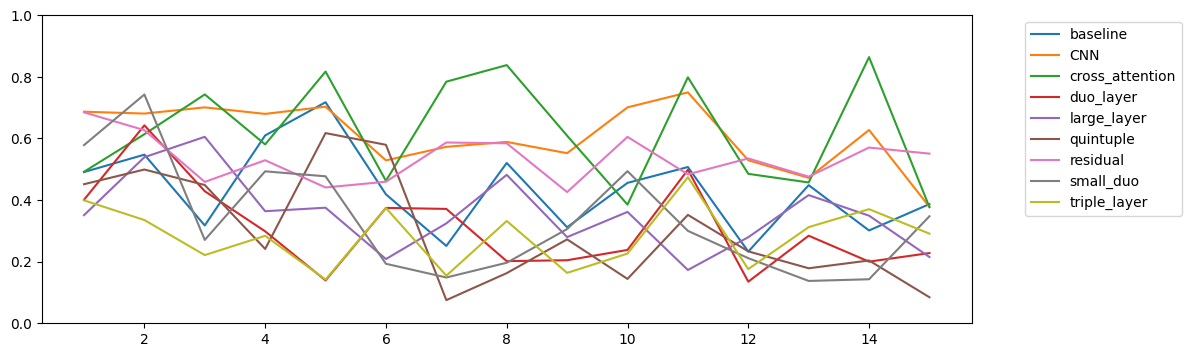

In [31]:
plt.figure(figsize=(12, 4))
for name, model in screening.items():
    plt.plot(range(1, 16), model["train_loss"], label=name)
plt.ylim(0, 1)
plt.legend(bbox_to_anchor=(1.05, 1))

In [ ]:
_, (roc, prc) = plt.subplots(1, 2, figsize=(12, 5))

for name, model in screening.items():
    pass

# TODO run an evaluation of the models
# you will have to manually load the weights onto the right model class
# this might take too long...
# Imma just do this locally and save it to history

IndentationError: expected an indented block (4135855484.py, line 3)